# Interpolação 1D

## Definição do sinal a ser utilizado

Text(0, 0.5, 'signal(x)')

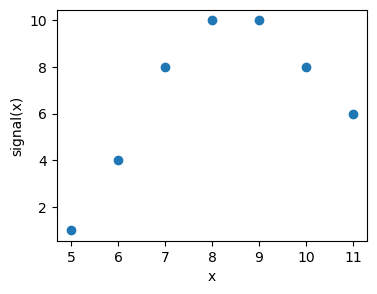

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(5, 12)
signal = [1, 4, 8, 10, 10, 8, 6]
plt.plot(x, signal, "o")
plt.xlabel("x")
plt.ylabel("signal(x)")

## 1. Interpolação de vizinho mais próximo

Queremos criar um novo sinal contendo mais pontos do que o sinal original. Primeiro faremos isso utilizando interpolação de vizinho mais próximo.

Text(0, 0.5, 'signal(x)')

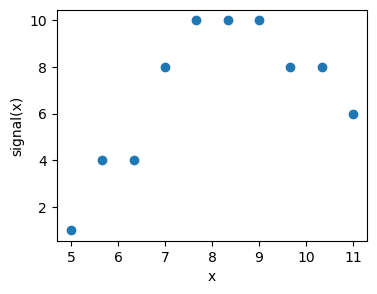

In [2]:
def nearest_neighbor_inter(x, y, output_size):
    
    x_min = x[0]
    x_max = x[-1]
    # O tamanho do intervalo entre os pontos originais é dado pelo intervalo total dividido pelo 
    # número de intervalos (que é o número de pontos menos 1)
    step_size = (x_max - x_min) / (len(x) - 1)

    # Cria os valores de x igualmente espaçados entre x_min e x_max
    x_interp = np.linspace(x_min, x_max, output_size)   
    
    y_interp = np.zeros_like(x_interp)
    for idx, x_c in enumerate(x_interp):
        
        closest_index = (x_c - x_min) / step_size
        closest_index = round(closest_index)

        y_interp[idx] = y[closest_index]
        
    return x_interp, y_interp

x_interp, signal_interp = nearest_neighbor_inter(x, signal, 10)

plt.plot(x_interp, signal_interp, "o")
plt.xlabel("x")
plt.ylabel("signal(x)")    

## 2. Interpolação linear

Suponha que $x$ é o ponto onde o valor do sinal é desconhecido. A interpolação linear envolve utilizarmos os valores conhecidos do sinal que estão imediatamente antes e depois do ponto $x$. Seja $x_e$ e $x_d$ esses dois pontos, e $y_e$ e $y_d$ o valor do sinal nesses dois pontos. Definimos então uma reta que passa por esses dois pontos utilizando a equação de reta

\begin{equation}
y(x) = y_e + \frac{y_d-y_e}{x_d-x_e}(x-x_e)
\end{equation}

Podemos então calcular o valor de $y(x)$ no ponto $x$ desconhecido.

Text(0, 0.5, 'signal(x)')

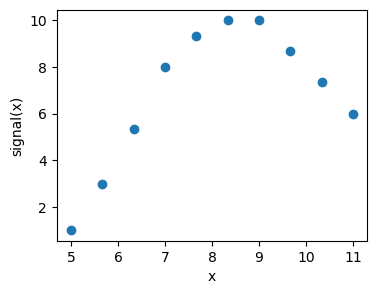

In [3]:
def linear_interpol(x, y, output_size):

    x_min = x[0]
    x_max = x[-1]
    # O tamanho do intervalo entre os pontos originais é dado pelo intervalo total dividido pelo 
    # número de intervalos (que é o número de pontos menos 1)
    step_size = (x_max - x_min) / (len(x) - 1)

    # Cria os valores de x igualmente espaçados entre x_min e x_max
    x_interp = np.linspace(x_min, x_max, output_size)   
    
    y_interp = np.zeros_like(x_interp)
    for idx_c, x_c in enumerate(x_interp):

        # Calcula o índice do ponto original mais próximo à esquerda de x_c
        idx_e = (x_c - x_min) / step_size
        idx_e = int(idx_e)

        # Condição para lidar com o último ponto, onde não há um ponto à direita
        if idx_e >= len(x) - 1:
            y_interp[idx_c] = y[-1]
            continue

        x_e = x[idx_e]
        x_d = x[idx_e + 1]
        y_e = y[idx_e]
        y_d = y[idx_e + 1]

        # Equação da reta entre os pontos (x_e, y_e) e (x_d, y_d) para encontrar o valor 
        # interpolado em x_c
        val = y_e + (x_c - x_e) * (y_d - y_e) / (x_d - x_e)
        y_interp[idx_c] = val

    return x_interp, y_interp

x_interp, signal_interp = linear_interpol(x, signal, 10)

plt.plot(x_interp, signal_interp, "o")
plt.xlabel("x")
plt.ylabel("signal(x)") 

## 3. Interpolação utilizando o scipy

Text(0, 0.5, 'signal(x)')

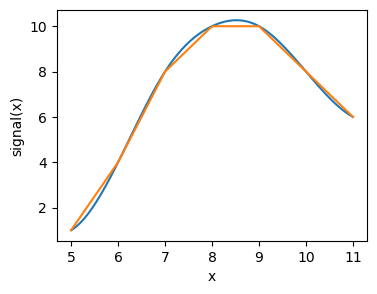

In [4]:
from scipy.interpolate import make_interp_spline

# Cria objeto de interpolação cúbica
bspl = make_interp_spline(x, signal, k=3)

# Calcula os valores interpolados
x_interp = np.linspace(x[0], x[-1], 100)
signal_interp = bspl(x_interp)

# Para comparação, também calculamos a interpolação linear usando k=1
bspl = make_interp_spline(x, signal, k=1)
signal_interp_linear = bspl(x_interp)

plt.plot(x_interp, signal_interp)
plt.plot(x_interp, signal_interp_linear)

plt.xlabel("x")
plt.ylabel("signal(x)")